In [1]:
# 3. Import the required packages with their customary aliases as follows:

In [2]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
gdp_df = pd.read_csv(r'C:\Users\chloe\Documents\NSS\Python\data\gdp_per_capita.csv')
gdp_df
# there are 8465 rows and 4 columns
# data types include country, year, gdp (number), and a footnote

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


In [4]:
# 5. How many rows and columns are in `gdp_df`? 
# What are the data types of each column?

gdp_df.shape

# there are 8465 rows and 3 columns

(8465, 4)

In [5]:
#  6. Drop the `Value Footnotes` column and rename the remaining three to 
# 'Country', 'Year', and 'GDP_Per_Capita'.

gdp_df = gdp_df.drop(columns=['Value Footnotes'])
gdp_df

,Country or Area,Year,Value
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [6]:
# # 7. How many countries have data for all years?

count_years =  gdp_df['Year'].nunique()
count_years 


35

In [7]:
countries_year_counts = gdp_df.groupby('Country or Area')['Year'].count()
countries_all_years = countries_year_counts[countries_year_counts == count_years]
countries_all_years

# There were 226 countries/regions that had gdp data for all years

Country or Area
Africa Eastern and Southern    35
Africa Western and Central     35
Albania                        35
Algeria                        35
Andorra                        35
                               ..
Vanuatu                        35
Viet Nam                       35
World                          35
Zambia                         35
Zimbabwe                       35
Name: Year, Length: 226, dtype: int64

In [8]:
# Which countries are missing many years of data? 

countries_year_counts = gdp_df.groupby('Country or Area')['Year'].count()
countries_some_years = countries_year_counts[countries_year_counts < count_years]
countries_some_years

# there were 21 countries or regions missing data for at least one year

Country or Area
Afghanistan                  24
Bhutan                       34
Cayman Islands               18
CuraÃ§ao                     25
Djibouti                     12
Faroe Islands                17
Greenland                    34
Kosovo                       17
Lebanon                      34
Montenegro                   28
Palau                        34
San Marino                   27
Serbia                       30
Sint Maarten (Dutch part)    16
Somalia, Fed. Rep.           34
Syrian Arab Republic         33
Tonga                        34
Turks and Caicos Islands     18
Tuvalu                       34
Virgin Islands (US)          21
West Bank and Gaza           31
Name: Year, dtype: int64

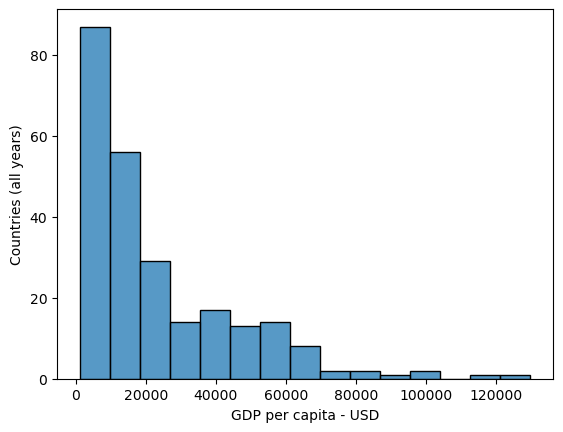

In [9]:
# In this question, 
# you're going to create some plots to show 
# the distribution of GDP per capita for the year 2020. 
# Go to the Python Graph Gallery (https://www.python-graph-gallery.com/) 
# and look at the different types of plots under the Distribution section. 
# Create a histogram, a density plot, a boxplot, and a violin plot.
# What do you notice when you look at these plots?
# How do the plots compare and 
# what information can you get out of one type
# that you can't necessarily get out of the others?

# Create a histogram, a density plot, a boxplot, and a violin plot. 
gdp_2020 = gdp_df[gdp_df["Year"] == 2020]

sns.histplot(data=gdp_2020, x="Value")
plt.xlabel("GDP per capita - USD")
plt.ylabel("Countries (all years)")
plt.show()

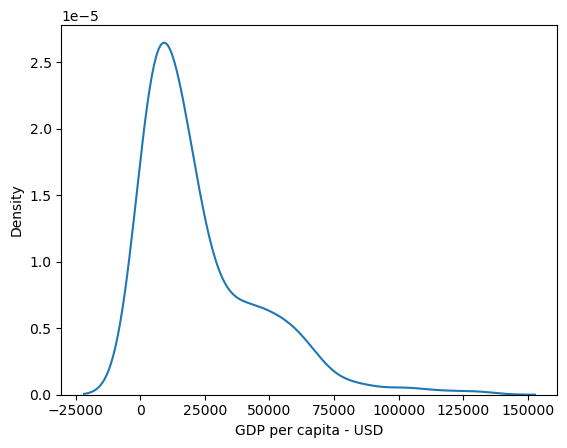

In [10]:
 # a density plot 
sns.kdeplot(data=gdp_2020, x="Value")
plt.xlabel("GDP per capita - USD")
plt.show()

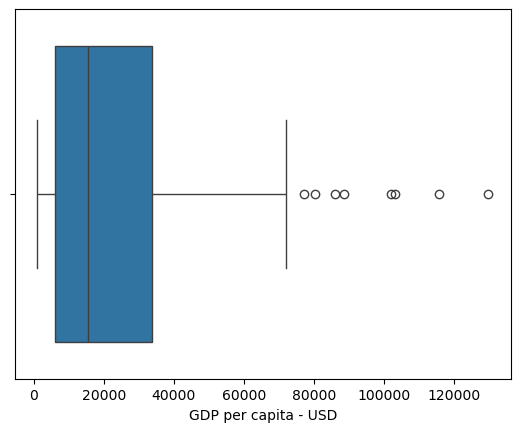

In [11]:
sns.boxplot(data=gdp_2020, x="Value")
plt.xlabel("GDP per capita - USD")
plt.show()

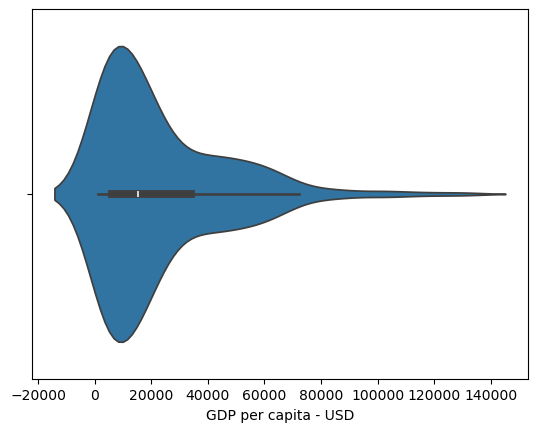

In [12]:
sns.violinplot(data=gdp_2020, x="Value")
plt.xlabel("GDP per capita - USD")
plt.show()

In [13]:
# 9. What was the median GDP per capita value in 2020?

median_2020 = gdp_2020["Value"].median()
median_2020


15399.308958012449

In [14]:
# Start by subsetting your data to just these 4 years 
# into a new DataFrame named gdp_decades.

gdp_decades = gdp_df[gdp_df["Year"].isin([1990, 2000, 2010, 2020])].reset_index()
gdp_decades

,index,Country or Area,Year,Value
0,3,Afghanistan,2020,2769.685745
1,13,Afghanistan,2010,2848.586061
2,23,Afghanistan,2000,1617.826475
3,28,Africa Eastern and Southern,2020,3978.931395
4,38,Africa Eastern and Southern,2010,3976.010989
...,...,...,...,...
961,8429,Zambia,1990,2425.111287
962,8434,Zimbabwe,2020,4527.719881
963,8444,Zimbabwe,2010,3885.393785
964,8454,Zimbabwe,2000,6170.333908


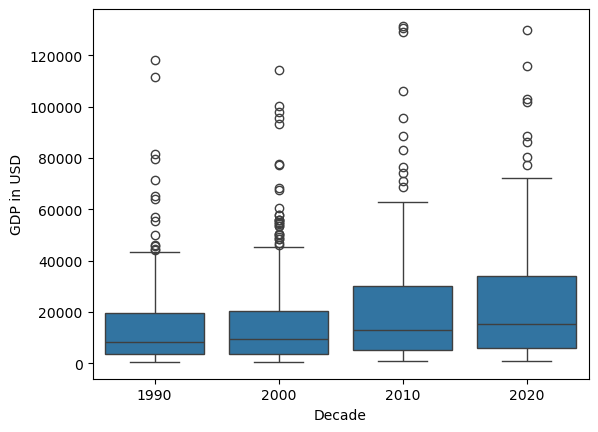

In [15]:
# 10. boxplot  

sns.boxplot(data=gdp_decades, x='Year', y='Value')
plt.xlabel("Decade")
plt.ylabel("GDP in USD")
plt.show()

# interesting to show how wealth inequality has stretched out, but not raised is floor

<BarContainer object of 966 artists>

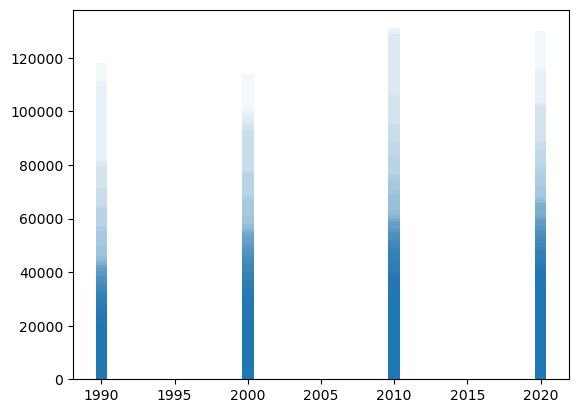

In [16]:
# 10. barplot 
plt.bar(x='Year',height='Value',data=gdp_decades, alpha=.05)
# good to show that low gdp is the global norm 

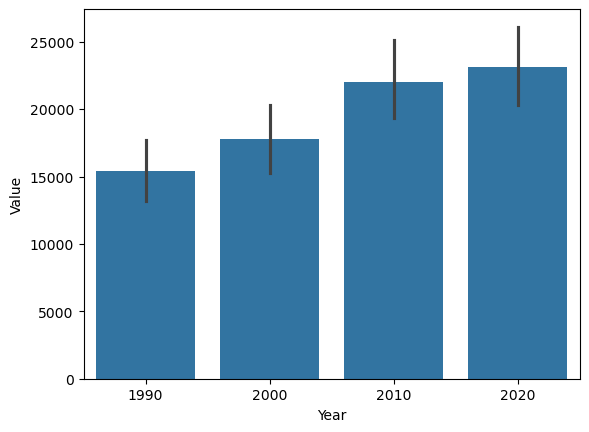

In [17]:
sns.barplot(data=gdp_decades, x='Year', y='Value')
plt.xlabel("Year")
plt.show()
# good to show the true mean of the data

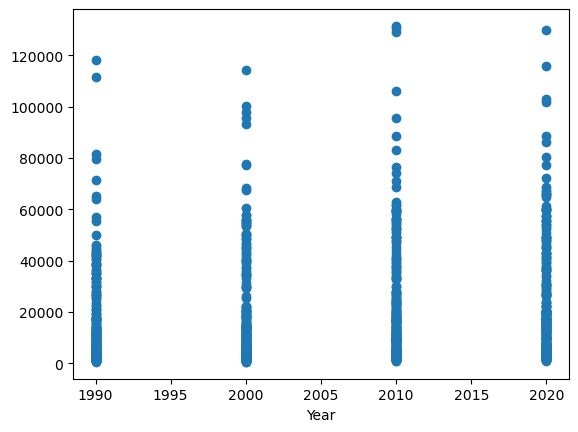

In [18]:
# 10. scatterplot

plt.scatter(data=gdp_decades,x='Year', y='Value')
plt.xlabel("Year")
plt.show()

# good to show the range of the data, and also how high gdp countries are outliers

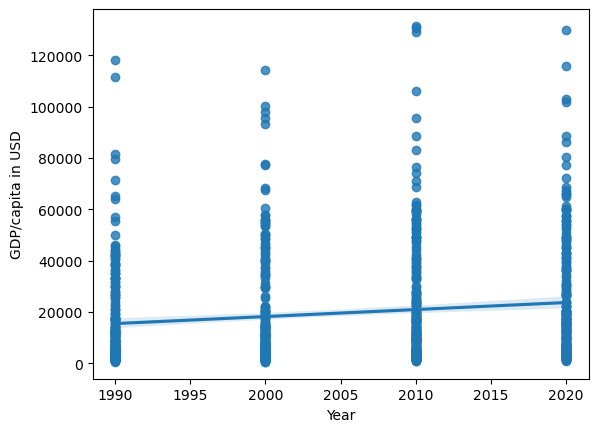

In [19]:
sns.regplot(data=gdp_decades,x='Year', y='Value')
plt.xlabel("Year")
plt.ylabel("GDP/capita in USD")
plt.show()
# decent to show the overall trend of increased gdp/capita but raises questions about inflation.

In [20]:
# 11. Which country was the first to have a GDP per capita greater than $100,000?

gdp_decades[gdp_decades["Value"]>100000][["Country or Area", "Year", "Value"]].reset_index()
# Brunei and UAE in 1990

,index,Country or Area,Year,Value
0,92,Bermuda,2010,105968.875104
1,117,Brunei Darussalam,2000,100323.439919
2,118,Brunei Darussalam,1990,118163.683370
3,419,Ireland,2020,101968.554362
4,529,Luxembourg,2020,129865.629988
5,530,Luxembourg,2010,131432.059616
6,531,Luxembourg,2000,114141.585296
7,534,"Macao SAR, China",2010,130758.280698
8,728,Qatar,2020,103061.899445
9,729,Qatar,2010,129044.708989


In [21]:
# 12. Which country had the highest GDP per capita in 2020? 
# Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

gdp_2020.sort_values(by='Value',ascending=False)
# Luxembourg had the highest GDP per capita in 2020. (129865 USD)

,Country or Area,Year,Value
4629,Luxembourg,2020,129865.629988
6778,Singapore,2020,115893.042396
6371,Qatar,2020,103061.899445
3668,Ireland,2020,101968.554362
798,Bermuda,2020,88618.083068
...,...,...,...
5357,Mozambique,2020,1466.124765
6969,"Somalia, Fed. Rep.",2020,1396.055447
1620,"Congo, Democratic Republic of",2020,1361.027911
1375,Central African Republic,2020,1136.570530


In [22]:
lux_df = gdp_df[gdp_df["Country or Area"]=="Luxembourg"][["Country or Area", "Year", "Value"]]
lux_df

,Country or Area,Year,Value
4625,Luxembourg,2024,128475.279803
4626,Luxembourg,2023,130048.920388
4627,Luxembourg,2022,132570.826463
4628,Luxembourg,2021,136772.443753
4629,Luxembourg,2020,129865.629988
4630,Luxembourg,2019,132724.752744
4631,Luxembourg,2018,131733.884649
4632,Luxembourg,2017,132169.834045
4633,Luxembourg,2016,133661.649729
4634,Luxembourg,2015,130097.256180


<Axes: xlabel='Year'>

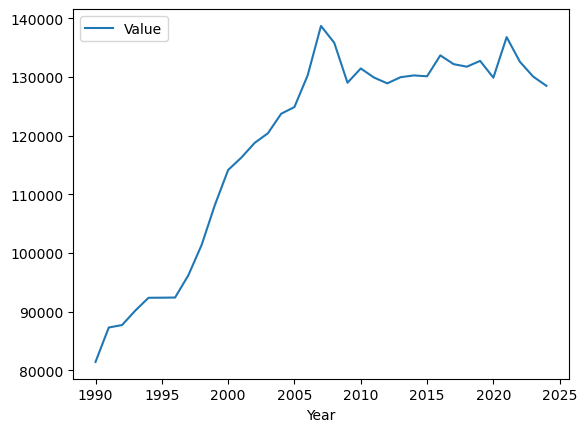

In [23]:
# Create a plot showing how Luxembourg's GDP per capita has changed over the timespan of the dataset.

# pd.plot(data=lux_df, x="Year", y="Value")
# plt.xlabel("GDP per capita - USD")
# plt.show()

lux_df.plot(x="Year", y="Value")

In [24]:
lux_df

,Country or Area,Year,Value
4625,Luxembourg,2024,128475.279803
4626,Luxembourg,2023,130048.920388
4627,Luxembourg,2022,132570.826463
4628,Luxembourg,2021,136772.443753
4629,Luxembourg,2020,129865.629988
4630,Luxembourg,2019,132724.752744
4631,Luxembourg,2018,131733.884649
4632,Luxembourg,2017,132169.834045
4633,Luxembourg,2016,133661.649729
4634,Luxembourg,2015,130097.256180


In [25]:
# Which country had the lowest GDP per capita in 2020? 
# Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

gdp_2020.sort_values(by='Value')
# Burundi had the lowest GDP 

burundi_df = gdp_df[gdp_df["Country or Area"] == "Burundi"]
burundi_df

,Country or Area,Year,Value
1108,Burundi,2024,1051.259313
1109,Burundi,2023,1036.167122
1110,Burundi,2022,1031.254122
1111,Burundi,2021,1035.538574
1112,Burundi,2020,1030.770264
1113,Burundi,2019,1057.950060
1114,Burundi,2018,1046.595112
1115,Burundi,2017,1023.970406
1116,Burundi,2016,1009.635968
1117,Burundi,2015,995.319068


<Axes: xlabel='Year'>

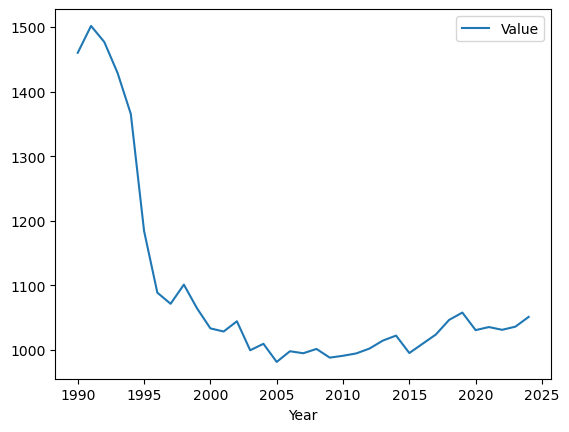

In [26]:
burundi_df.plot(x="Year", y="Value")

In [27]:
# BONUS: Bonus question:** Is it true in general that coutries had a higher GDP per capita in 2020 than in 1990? 
# Which countries had lower GDP per capita in 2020 than in 1990?

In [28]:
internet_df = pd.read_csv(r'C:\Users\chloe\Documents\NSS\Python\data\internet_use_per_capita.csv',
                         on_bad_lines='skip',
                         skipfooter=297,
                         engine='python'
)
internet_df.head()


,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.60,1
1,Afghanistan,2018,16.80,2
2,Afghanistan,2017,13.50,3
3,Afghanistan,2016,11.00,4
4,Afghanistan,2015,8.26,4


In [29]:
internet_df = internet_df.drop(columns=['Value Footnotes'])

In [30]:
internet_df = internet_df.rename(columns={"Country or Area": "Country", "Value":"Internet_Users_Pct"})
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


In [31]:
above_zero_pct = internet_df[internet_df['Internet_Users_Pct'] > 0]
sort_above_zero_pct = above_zero_pct.sort_values(by='Year')
sort_above_zero_pct
# above_zero_pct.sort_values(by='Year', ascending=False)

# 1990 is the first year to have non-zero internet users

,Country,Year,Internet_Users_Pct
1570,Denmark,1990,0.097277
2892,Japan,1990,0.020294
306,Australia,1990,0.585095
2034,France,1990,0.052778
339,Austria,1990,0.130369
...,...,...,...
427,Bangladesh,2023,44.502700
677,Bosnia and Herzegovina,2023,83.377200
1656,Ecuador,2023,72.694300
1537,Denmark,2023,98.775600
